### Analyzing all the data I got from final-file.ipynb which was converted to a csv. It contains the logistic model for 2022 and 2023

In [61]:
import pandas as pd
from collections import defaultdict

In [62]:
%load_ext rpy2.ipython
%load_ext autoreload
%autoreload 2

%matplotlib inline  
from matplotlib import rcParams
rcParams['figure.figsize'] = (16, 100)

import warnings
from rpy2.rinterface import RRuntimeWarning
warnings.filterwarnings("ignore") # Ignore all warnings
# warnings.filterwarnings("ignore", category=RRuntimeWarning) # Show some warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# show all columns
pd.set_option("display.max_columns", None)

In [63]:
%%javascript
// Disable auto-scrolling
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [64]:
%%R

require('tidyverse')
require('DescTools')
require('ggplot2')
require('dplyr')


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Loading required package: tidyverse
Loading required package: DescTools


In [45]:
df = pd.read_csv("final-analysis-df.csv")
df

,date,tournament,surface,five_set,player_A_name,player_B_name,player_A_elo_before,player_B_elo_before,player_A_win,elo_difference,surface_cluster_A,surface_cluster_B,predict_proba_R,predict_R
0,20230814,Cincinnati Masters,Hard,False,Max Purcell,Carlos Alcaraz,1407.244745,1945.383266,0,-538.138522,0,3,0.040547,0
1,20230828,Us Open,Hard,True,Alexandre Muller,Novak Djokovic,1496.436528,1996.029186,0,-499.592659,3,3,0.022841,0
2,20231123,Davis Cup Finals QF: SRB vs GBR,Hard,False,Cameron Norrie,Novak Djokovic,1552.741121,2027.908039,0,-475.166918,3,3,0.130107,0
3,20230320,Miami Masters,Hard,False,Facundo Bagnis,Carlos Alcaraz,1393.392591,1859.038006,0,-465.645415,1,3,0.074004,0
4,20230227,Dubai,Hard,False,Tomas Machac,Novak Djokovic,1478.222118,1935.465898,0,-457.243780,1,3,0.076454,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5736,20230807,Canada Masters,Hard,False,Carlos Alcaraz,Ben Shelton,1954.287094,1453.250492,1,501.036602,3,3,0.899484,1
5737,20230703,Wimbledon,Grass,True,Carlos Alcaraz,Jeremy Chardy,1974.653652,1472.158654,1,502.494998,3,2,0.984285,1
5738,20230828,Us Open,Hard,True,Novak Djokovic,Bernabe Zapata Miralles,1994.648405,1468.035237,1,526.613168,3,1,0.989001,1
5739,20230508,Rome Masters,Clay,False,Carlos Alcaraz,Albert Ramos,1919.446216,1391.795830,1,527.650386,3,1,0.934298,1


## See all rows where prediction went wrong

In [47]:
df_filtered = df[df['player_A_win'] != df['predict_R']].sort_values(by='predict_proba_R', ascending=False)
df_filtered

,date,tournament,surface,five_set,player_A_name,player_B_name,player_A_elo_before,player_B_elo_before,player_A_win,elo_difference,surface_cluster_A,surface_cluster_B,predict_proba_R,predict_R
5626,20230828,Us Open,Hard,True,Holger Rune,Roberto Carballes Baena,1771.489875,1511.918036,0,259.571839,3,1,0.919993,1
5726,20230508,Rome Masters,Clay,False,Carlos Alcaraz,Fabian Marozsan,1920.819154,1509.091278,0,411.727876,3,1,0.897412,1
5513,20230529,Roland Garros,Clay,True,Felix Auger Aliassime,Fabio Fognini,1666.621520,1455.022895,0,211.598625,3,1,0.888230,1
5718,20230102,Adelaide 1,Hard,False,Felix Auger Aliassime,Alexei Popyrin,1776.502854,1391.430115,0,385.072739,3,1,0.886661,1
5730,20230424,Madrid Masters,Clay,False,Daniil Medvedev,Aslan Karatsev,1883.343270,1437.913096,0,445.430174,3,3,0.876364,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,20230724,Hamburg,Clay,False,Daniel Altmaier,Andrey Rublev,1431.691637,1818.580464,1,-386.888827,1,3,0.100051,0
269,20220829,Us Open,Hard,True,Brandon Holt,Taylor Fritz,1484.183661,1684.664234,1,-200.480573,0,3,0.079260,0
39,20230116,Australian Open,Hard,True,Alexei Popyrin,Taylor Fritz,1407.601871,1739.865294,1,-332.263424,1,3,0.041724,0
21,20230529,Roland Garros,Clay,True,Daniel Altmaier,Jannik Sinner,1389.270646,1768.999150,1,-379.728505,1,3,0.029323,0


In [48]:
upsets_df = df_filtered[df_filtered['predict_R'] == 1]
upsets_df

,date,tournament,surface,five_set,player_A_name,player_B_name,player_A_elo_before,player_B_elo_before,player_A_win,elo_difference,surface_cluster_A,surface_cluster_B,predict_proba_R,predict_R
5626,20230828,Us Open,Hard,True,Holger Rune,Roberto Carballes Baena,1771.489875,1511.918036,0,259.571839,3,1,0.919993,1
5726,20230508,Rome Masters,Clay,False,Carlos Alcaraz,Fabian Marozsan,1920.819154,1509.091278,0,411.727876,3,1,0.897412,1
5513,20230529,Roland Garros,Clay,True,Felix Auger Aliassime,Fabio Fognini,1666.621520,1455.022895,0,211.598625,3,1,0.888230,1
5718,20230102,Adelaide 1,Hard,False,Felix Auger Aliassime,Alexei Popyrin,1776.502854,1391.430115,0,385.072739,3,1,0.886661,1
5730,20230424,Madrid Masters,Clay,False,Daniil Medvedev,Aslan Karatsev,1883.343270,1437.913096,0,445.430174,3,3,0.876364,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2323,20220915,Davis Cup Finals RR: FRA vs AUS,Hard,False,Jason Kubler,Richard Gasquet,1556.351295,1577.634387,0,-21.283093,3,3,0.500582,1
2589,20220829,Us Open,Hard,True,Jack Draper,Karen Khachanov,1602.182968,1613.779753,0,-11.596785,3,3,0.500555,1
1486,20221024,Vienna,Hard,False,Oscar Otte,Daniel Evans,1487.683595,1551.033709,0,-63.350114,3,2,0.500456,1
4136,20230916,Davis Cup Finals RR: AUS vs SUI,Hard,False,Dominic Stricker,Thanasi Kokkinakis,1570.555192,1516.929433,0,53.625759,1,1,0.500316,1


### player that caused most upsets

In [49]:
upsets_df['player_B_name'].value_counts().sort_values(ascending=False).reset_index()

,player_B_name,count
0,Casper Ruud,17
1,Diego Schwartzman,16
2,Dusan Lajovic,15
3,Lorenzo Musetti,15
4,Borna Coric,14
...,...,...
201,Jack Sock,1
202,Carlos Taberner,1
203,Gijs Brouwer,1
204,Mark Lajal,1


### player who was defeated most when expected to win

In [50]:
upsets_df['player_A_name'].value_counts().sort_values(ascending=False)

player_A_name
Roberto Bautista Agut    26
Felix Auger Aliassime    24
Lorenzo Musetti          21
Alex De Minaur           19
Cameron Norrie           18
                         ..
Milos Raonic              1
Nicolas Mejia             1
Pedro Cachin              1
Daniel Cukierman          1
Pablo Andujar             1
Name: count, Length: 162, dtype: int64

In [51]:
upsets_df[upsets_df['player_A_name'] == 'Roberto Bautista Agut']

,date,tournament,surface,five_set,player_A_name,player_B_name,player_A_elo_before,player_B_elo_before,player_A_win,elo_difference,surface_cluster_A,surface_cluster_B,predict_proba_R,predict_R
5323,20220718,Gstaad,Clay,False,Roberto Bautista Agut,Juan Pablo Varillas,1611.981681,1443.123413,0,168.858268,3,1,0.759670,1
5019,20220829,Us Open,Hard,True,Roberto Bautista Agut,J J Wolf,1641.002046,1517.637891,0,123.364155,3,3,0.739164,1
4469,20230529,Roland Garros,Clay,True,Roberto Bautista Agut,Juan Pablo Varillas,1544.379067,1469.439077,0,74.939990,3,1,0.735031,1
5119,20230206,Montpellier,Hard,False,Roberto Bautista Agut,Arthur Fils,1643.958460,1508.620476,0,135.337985,3,1,0.733095,1
5410,20230220,Doha,Hard,False,Roberto Bautista Agut,Christopher Oconnell,1610.220821,1423.243697,0,186.977123,3,3,0.705826,1
5073,20220502,Madrid Masters,Clay,False,Roberto Bautista Agut,Daniel Evans,1618.948174,1489.586024,0,129.362151,3,2,0.692009,1
4580,20230717,Gstaad,Clay,False,Roberto Bautista Agut,Pedro Cachin,1571.696125,1487.988626,0,83.707498,3,1,0.688686,1
4570,20220815,Cincinnati Masters,Hard,False,Roberto Bautista Agut,Borna Coric,1659.517171,1576.557013,0,82.960159,3,1,0.688014,1
5150,20221017,Naples,Hard,False,Roberto Bautista Agut,Mackenzie Mcdonald,1643.017919,1503.423673,0,139.594246,3,3,0.662981,1
4669,20230109,Adelaide 2,Hard,False,Roberto Bautista Agut,Soon Woo Kwon,1637.536745,1547.243020,0,90.293725,3,2,0.656059,1


In [17]:
shock_wins = df_filtered[df_filtered['predict_R'] == 0]
shock_wins

,date,tournament,surface,five_set,player_A_name,player_B_name,player_A_elo_before,player_B_elo_before,player_A_win,elo_difference,player_A_cluster,player_B_cluster,predict_proba_R,predict_R
1251,20230417,Barcelona,Clay,False,Francisco Cerundolo,Casper Ruud,1545.164825,1554.828282,1,-9.663457,2,1,0.499258,0
1650,20230220,Doha,Hard,False,Andy Murray,Alexandre Muller,1525.561855,1513.892367,1,11.669488,0,1,0.499061,0
1673,20230109,Adelaide 2,Hard,False,Jason Kubler,Tomas Martin Etcheverry,1513.088544,1500.000000,1,13.088544,2,2,0.498826,0
895,20231016,Antwerp,Hard,False,Botic Van De Zandschulp,Dominic Stricker,1482.323340,1515.454093,1,-33.130752,2,0,0.498675,0
1291,20230703,Wimbledon,Grass,True,Jiri Lehecka,Tommy Paul,1589.691213,1596.568474,1,-6.877260,0,0,0.498144,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26,20230807,Canada Masters,Hard,False,Tommy Paul,Carlos Alcaraz,1599.815682,1871.224406,1,-271.408724,2,2,0.165204,0
31,20231002,Shanghai Masters,Hard,False,Diego Schwartzman,Taylor Fritz,1430.020839,1691.123998,1,-261.103159,1,2,0.164867,0
13,20230724,Hamburg,Clay,False,Daniel Altmaier,Andrey Rublev,1446.236069,1742.110979,1,-295.874910,1,1,0.155912,0
53,20230529,Roland Garros,Clay,True,Daniel Altmaier,Jannik Sinner,1458.158735,1690.906010,1,-232.747274,1,1,0.089383,0


### prediction was for this player to have lost, but they won!

In [18]:
shock_wins['player_B_name'].value_counts().sort_values(ascending=False)

player_B_name
Sebastian Baez         13
Taylor Fritz           11
Stan Wawrinka          11
Tommy Paul             10
Nicolas Jarry           9
                       ..
Timofey Skatov          1
Luca Nardi              1
Eliot Spizzirri         1
Alexander Ritschard     1
Yoshihito Nishioka      1
Name: count, Length: 187, dtype: int64

### prediction was for this player to win, but they lost

In [19]:
shock_wins['player_A_name'].value_counts().sort_values(ascending=False)

player_A_name
Alexander Zverev           10
Alexander Bublik           10
Botic Van De Zandschulp     9
Roman Safiullin             9
Miomir Kecmanovic           9
                           ..
Mate Valkusz                1
Mitchell Krueger            1
Omni Kumar                  1
James Duckworth             1
Thiago Seyboth Wild         1
Name: count, Length: 168, dtype: int64

### Who caused the most upsets in a long match

In [71]:
long_matches = df_filtered[(df_filtered['five_set'] == True) & (df_filtered['player_A_win'] == 1)]
long_matches['player_A_name'].value_counts()

player_A_name
Casper Ruud           5
Diego Schwartzman     4
Daniel Evans          3
Matteo Berrettini     3
Ben Shelton           3
                     ..
Guido Pella           1
Harold Mayot          1
Emilio Nava           1
Tomas Barrios Vera    1
Alexei Popyrin        1
Name: count, Length: 101, dtype: int64

### Who performed better during a long match

In [77]:
long_matches_overall = df[(df['five_set'] == True) & (df['player_A_win'] == 1)]
long_matches_overall['player_A_name'].value_counts().head(50)

player_A_name
Carlos Alcaraz                 19
Novak Djokovic                 16
Jannik Sinner                  13
Casper Ruud                    13
Andrey Rublev                  12
Alex De Minaur                 12
Daniil Medvedev                12
Stefanos Tsitsipas             11
Rafael Nadal                   10
Denis Shapovalov                8
Hubert Hurkacz                  8
Karen Khachanov                 8
Alexander Zverev                8
Cameron Norrie                  8
Holger Rune                     8
Felix Auger Aliassime           6
Adrian Mannarino                6
Tommy Paul                      6
Alejandro Davidovich Fokina     6
Tallon Griekspoor               5
Jason Kubler                    5
Marin Cilic                     5
David Goffin                    5
Botic Van De Zandschulp         5
Grigor Dimitrov                 5
Pablo Carreno Busta             5
Sebastian Korda                 5
Matteo Berrettini               5
Daniel Evans                    5


[1] "integer"


In [78]:
%%R -i long_matches_overall

# Step 1: Filter for 5-set wins as Player A and count them
long_match_wins <- long_matches_overall %>%
  filter(five_set == TRUE, player_A_win == 1) %>%
  count(player_A_name, sort = TRUE) %>%
  top_n(50, n)  # get top 50 players

# Optional: rename for clarity
colnames(long_match_wins) <- c("player", "wins")


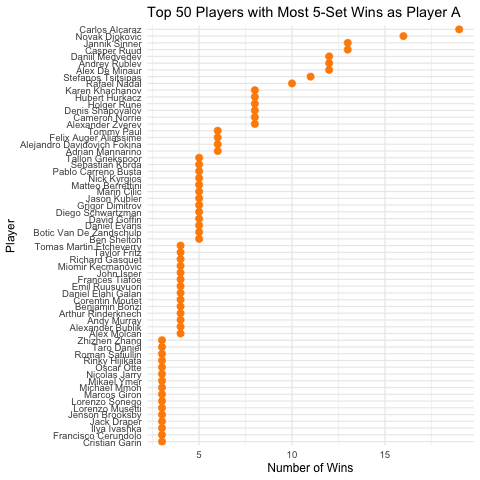

In [79]:
%%R
ggplot(long_match_wins, aes(x = reorder(player, wins), y = wins)) +
  geom_point(size = 3, color = "darkorange") +
  coord_flip() +
  labs(
    title = "Top 50 Players with Most 5-Set Wins as Player A",
    x = "Player",
    y = "Number of Wins"
  ) +
  theme_minimal(base_size = 12)


### ^^ They're all top players!

### Analyzing 2024 data